## 药物Shap值的整合与可视化

In [ ]:
import pandas as pd
import os
import sys
import shap
scripts_path = os.path.abspath('../scripts')
if scripts_path not in sys.path:
    sys.path.append(scripts_path)

from explain_tools import get_combine_shap,mol_picture

In [1]:
Drug1_name = 'tamoxifen'
Drug2_name = 'docetaxel'
cell_line_name = 'NCIH838'

In [2]:

name_cids = pd.read_pickle("../data/SHAP/DrugComb_all_witch_CID_data_name2_CID_dict.pkl")

drug_cid_1 = str(name_cids[Drug1_name])
drug_cid_2 = str(name_cids[Drug2_name])

drug_shap_dir = '../data/SHAP'

drug_shap_1 = pd.read_csv(drug_shap_dir + '/' + drug_cid_1 + '_shap.csv', index_col=0)
drug_shap_2 = pd.read_csv(drug_shap_dir + '/' + drug_cid_2 + '_shap.csv', index_col=0)
drug_shap_1.fillna("", inplace=True)
drug_shap_2.fillna("", inplace=True)

In [3]:
mid_shap_dir = f'../data/SHAP/mid_shap_test_{Drug1_name}_{Drug2_name}_{cell_line_name}.csv'
mid_shap = pd.read_csv(mid_shap_dir)

In [5]:


drug_f1_comb_shap = get_combine_shap(drug_shap_1,mid_shap, 'drug_f1')
drug_f2_comb_shap = get_combine_shap(drug_shap_2,mid_shap, 'drug_f2')

In [6]:
explanation1 = shap.Explanation(
    values= drug_f1_comb_shap,
    base_values= 0.0,
    data=drug_shap_1['smiles'].to_list(),
)

explanation2 = shap.Explanation(
    values= drug_f2_comb_shap,
    base_values= 0.0,
    data=drug_shap_2['smiles'].to_list(),
)

In [7]:
shap.plots.text(explanation1, display=True)

Reconstructed SMILES string: CC/C(=C(\c1ccccc1)c1ccc(OCCN(C)C)cc1)c1ccccc1
Successfully mapped SHAP values to 28 out of 28 atoms.


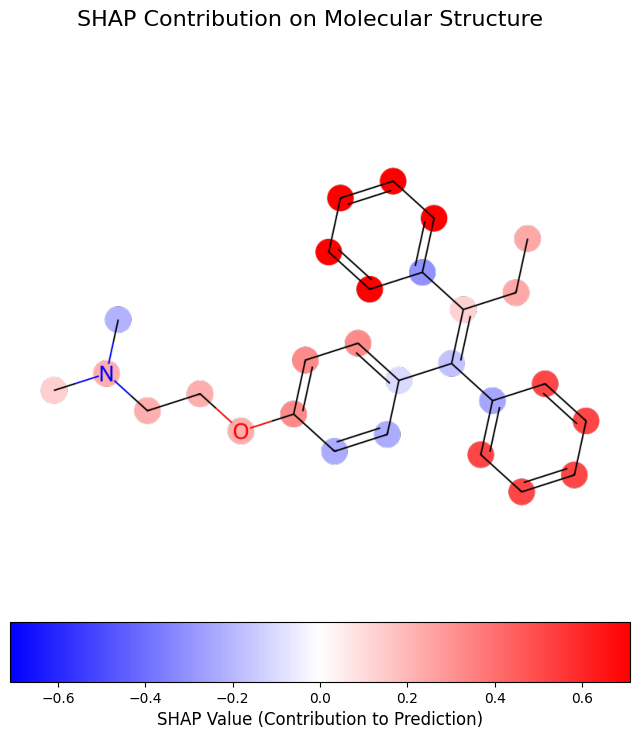

In [10]:
save_path = f'../data/SHAP/{Drug1_name}.pdf'

mol_picture(drug_f1_comb_shap*100,drug_shap_1['smiles'].to_list(),save_path,AtomIndices=False)

In [11]:
shap.plots.text(explanation2, display=True)

Reconstructed SMILES string: CC(=O)O[C@@]12CO[C@@H]1C[C@H](O)[C@@]1(C)C(=O)[C@H](O)C3=C(C)[C@@H](OC(=O)[C@H](O)[C@@H](NC(=O)OC(C)(C)C)c4ccccc4)C[C@@](O)([C@@H](OC(=O)c4ccccc4)[C@H]21)C3(C)C
Successfully mapped SHAP values to 58 out of 58 atoms.


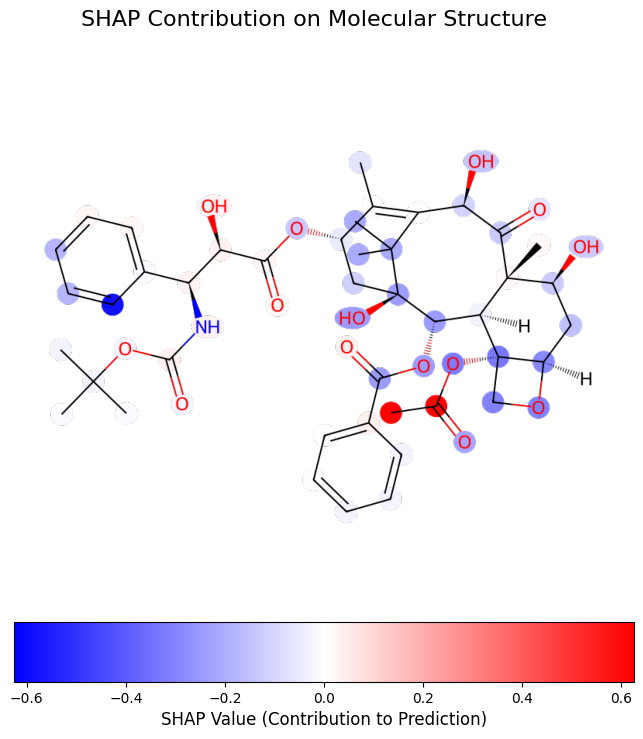

In [12]:
save_path = f'../data/SHAP/{Drug2_name}.pdf'

mol_picture(drug_f2_comb_shap*100,drug_shap_2['smiles'].to_list(),save_path,AtomIndices=False)